# Automatic differentiation for a sigmoid neuron

This notebook studies a single sigmoid neuron with a regularized loss. The goal is to understand how the same gradient can be obtained in three different ways:

- by direct differentiation,
- by **forward mode** automatic differentiation,
- by **reverse mode** automatic differentiation.

We use the scalar model

$$
z = wx+b, \qquad \hat y = \sigma(z)=\frac{1}{1+e^{-z}},
$$

with regularized loss

$$
L(w,b)=\frac12(\hat y-t)^2+\frac{\lambda}{2}w^2.
$$


## Learning goals

By the end of the exercise you should be able to:

1. write the intermediate variables of a simple computational graph,
2. compute the gradient of the loss by hand,
3. propagate a directional derivative with **forward mode**,
4. propagate adjoints with **reverse mode**,
5. compare the manual result with autodiff in **JAX**.


## 1. Imports and reference point

We will use one numerical example throughout the notebook. You can change these values later and rerun the cells.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reference point
x = 2.0
t = 1.0
w = 0.5
b = -1.0
lam = 0.1

print(f"x={x}, t={t}, w={w}, b={b}, lambda={lam}")


x=2.0, t=1.0, w=0.5, b=-1.0, lambda=0.1


## 2. The computational graph

For one data point, the data branch is

$$
w,b,x \longrightarrow z=wx+b \longrightarrow \hat y=\sigma(z) \longrightarrow L_{	\text{data}}=\frac12(\hat y-t)^2.
$$

The regularization branch is

$$
w \longrightarrow L_{\text{reg}}=\frac{\lambda}{2}w^2.
$$

The final loss is

$$
L = L_{\text{data}} + L_{\text{reg}}.
$$

### Exercise 1

Implement the forward pass and store all intermediate quantities in a dictionary. Then inspect which variables depend directly on $w$ and which node is the output of the graph.


In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def forward_graph(w, b, x, t, lam):
    z = w * x + b
    y_hat = sigmoid(z)
    loss_data = 0.5 * (y_hat - t) ** 2
    loss_reg = 0.5 * lam * w ** 2
    loss = loss_data + loss_reg

    return {
        "z": z,
        "y_hat": y_hat,
        "loss_data": loss_data,
        "loss_reg": loss_reg,
        "loss": loss,
    }


cache = forward_graph(w, b, x, t, lam)
cache


{'z': 0.0,
 'y_hat': np.float64(0.5),
 'loss_data': np.float64(0.125),
 'loss_reg': 0.0125,
 'loss': np.float64(0.1375)}

In [3]:
for key, value in cache.items():
    print(f"{key:>10s} : {value:.6f}")


         z : 0.000000
     y_hat : 0.500000
 loss_data : 0.125000
  loss_reg : 0.012500
      loss : 0.137500


## 3. Closed-form derivatives

Since

$$
\frac{d}{dz}\sigma(z)=\sigma(z)\bigl(1-\sigma(z)\bigr),
$$

we obtain

$$
\frac{\partial L}{\partial z} = (\hat y-t)\,\hat y(1-\hat y).
$$

Therefore,

$$
\frac{\partial L}{\partial w}
= \frac{\partial L}{\partial z}\frac{\partial z}{\partial w} + \lambda w
= (\hat y-t)\,\hat y(1-\hat y)\,x + \lambda w,
$$

and

$$
\frac{\partial L}{\partial b}
= \frac{\partial L}{\partial z}\frac{\partial z}{\partial b}
= (\hat y-t)\,\hat y(1-\hat y).
$$

### Exercise 2

Implement a function that returns the two partial derivatives at the reference point.


In [5]:
def closed_form_gradients(w, b, x, t, lam):
   z = w * x + b
   y_hat = sigmoid(z)
   delta = (y_hat - t) * y_hat * (1.0 - y_hat)
   dL_dw = delta * x + lam * w
   dL_db = delta
   return dL_dw, dL_db


dL_dw_closed, dL_db_closed = closed_form_gradients(w, b, x, t, lam)
print("Closed-form gradients")
print("dL/dw =", dL_dw_closed)
print("dL/db =", dL_db_closed)


Closed-form gradients
dL/dw = -0.2
dL/db = -0.125


## 4. Manual forward mode

Forward mode propagates **tangents**. For a parameter-space direction $(\dot w, \dot b)$, the tangent variables satisfy

$$
\dot z = x\,\dot w + \dot b,
$$

$$
\dot{\hat y} = \sigma'(z)\,\dot z = \hat y(1-\hat y)\dot z,
$$

$$
\dot L_{\text{data}} = (\hat y-t)\,\dot{\hat y},
$$

$$
\dot L_{\text{reg}} = \lambda w\,\dot w,
$$

$$
\dot L = \dot L_{\text{data}} + \dot L_{\text{reg}}.
$$

### Exercise 3

Implement one forward-mode sweep. The output `loss_dot` is the directional derivative of $L$ in the chosen direction.


In [6]:
def forward_mode_jvp(w, b, x, t, lam, w_dot, b_dot):
    # primal values
    z = w * x + b
    y_hat = sigmoid(z)
    loss_data = 0.5 * (y_hat - t) ** 2
    loss_reg = 0.5 * lam * w ** 2
    loss = loss_data + loss_reg

    # tangent values
    z_dot = x * w_dot + b_dot
    y_hat_dot = y_hat * (1.0 - y_hat) * z_dot
    loss_data_dot = (y_hat - t) * y_hat_dot
    loss_reg_dot = lam * w * w_dot
    loss_dot = loss_data_dot + loss_reg_dot

    return {
        "loss": loss,
        "loss_dot": loss_dot,
        "z": z,
        "z_dot": z_dot,
        "y_hat": y_hat,
        "y_hat_dot": y_hat_dot,
    }


Use the basis directions

$$
e_1=(1,0), \qquad e_2=(0,1),
$$

to recover the two partial derivatives.


In [7]:
jvp_e1 = forward_mode_jvp(w, b, x, t, lam, w_dot=1.0, b_dot=0.0)
jvp_e2 = forward_mode_jvp(w, b, x, t, lam, w_dot=0.0, b_dot=1.0)

print("Forward mode with e1 = (1,0): loss_dot =", jvp_e1["loss_dot"])
print("Forward mode with e2 = (0,1): loss_dot =", jvp_e2["loss_dot"])
print()
print("Recovered gradient from forward mode:")
print("dL/dw =", jvp_e1["loss_dot"])
print("dL/db =", jvp_e2["loss_dot"])


Forward mode with e1 = (1,0): loss_dot = -0.2
Forward mode with e2 = (0,1): loss_dot = -0.125

Recovered gradient from forward mode:
dL/dw = -0.2
dL/db = -0.125


### Optional check with an arbitrary direction

Forward mode is especially useful when we want a directional derivative without computing the full gradient.


In [8]:
direction = np.array([0.3, -0.7])
jvp_dir = forward_mode_jvp(w, b, x, t, lam, w_dot=direction[0], b_dot=direction[1])

print("Direction =", direction)
print("JVP =", jvp_dir["loss_dot"])


Direction = [ 0.3 -0.7]
JVP = 0.027499999999999997


### Optional check with finite differences

For a small step $\varepsilon$,

$$
\frac{L(w+\varepsilon \dot w,\; b+\varepsilon \dot b)-L(w,b)}{\varepsilon} \approx \dot L.
$$

This is a numerical sanity check, not automatic differentiation.


In [9]:
def loss_only(w, b, x, t, lam):
    return forward_graph(w, b, x, t, lam)["loss"]


def finite_difference_directional_derivative(w, b, x, t, lam, w_dot, b_dot, eps=1e-6):
    base = loss_only(w, b, x, t, lam)
    shifted = loss_only(w + eps * w_dot, b + eps * b_dot, x, t, lam)
    return (shifted - base) / eps


fd_dir = finite_difference_directional_derivative(
    w, b, x, t, lam, direction[0], direction[1]
)

print("Finite-difference directional derivative =", fd_dir)
print("Forward-mode directional derivative      =", jvp_dir["loss_dot"])
print("Absolute difference                     =", abs(fd_dir - jvp_dir["loss_dot"]))


Finite-difference directional derivative = 0.02750000482887316
Forward-mode directional derivative      = 0.027499999999999997
Absolute difference                     = 4.828873162443514e-09


## 5. Manual reverse mode

We start from the seed
$$
\bar L = 1.
$$

Reverse mode propagates **adjoints** backward through the graph. For each intermediate variable $v$, define
$$
\bar v = \frac{\partial L}{\partial v}.
$$

### Exercise 4

Implement a manual reverse sweep and keep track of the two contributions to the gradient with respect to $w$.


In [20]:
def reverse_mode_backprop(w, b, x, t, lam):
    cache = forward_graph(w, b, x, t, lam)

    # Read primal values
    y_hat = cache["y_hat"]

    # Output seed
    loss_bar = 1.0

    # L = loss_data + loss_reg
    loss_data_bar = loss_bar
    loss_reg_bar = loss_bar

    # loss_data = 0.5 * (y_hat - t)^2
    y_hat_bar = loss_data_bar * (y_hat - t)

    # loss_reg = 0.5 * lam * w^2
    w_bar_from_reg = loss_reg_bar * lam * w

    # y_hat = sigmoid(z)
    z_bar = y_hat_bar * y_hat * (1.0 - y_hat)

    # z = w*x + b
    w_bar_from_data = z_bar * x
    b_bar = z_bar

    # Accumulate contributions to w
    w_bar = w_bar_from_data + w_bar_from_reg

    return {
        "w_bar": w_bar,
        "b_bar": b_bar,
        "z_bar": z_bar,
        "w_bar_from_data": w_bar_from_data,
        "w_bar_from_reg": w_bar_from_reg,
    }


backprop = reverse_mode_backprop(w, b, x, t, lam)
backprop


{'w_bar': np.float64(-0.2),
 'b_bar': np.float64(-0.125),
 'z_bar': np.float64(-0.125),
 'w_bar_from_data': np.float64(-0.25),
 'w_bar_from_reg': 0.05}

In [11]:
print("Reverse-mode gradients")
print("dL/dw =", backprop["w_bar"])
print("dL/db =", backprop["b_bar"])
print()
print("Contribution to dL/dw from data term:", backprop["w_bar_from_data"])
print("Contribution to dL/dw from reg term :", backprop["w_bar_from_reg"])


Reverse-mode gradients
dL/dw = -0.2
dL/db = -0.125

Contribution to dL/dw from data term: -0.25
Contribution to dL/dw from reg term : 0.05


## 6. Compare the three gradients

Verify that

- forward mode with seeds $e_1$ and $e_2$,
- manual reverse mode,
- the closed-form formulas,

all give the same gradient.


In [12]:
dL_dw_closed, dL_db_closed = closed_form_gradients(w, b, x, t, lam)
grad_forward = np.array([jvp_e1["loss_dot"], jvp_e2["loss_dot"]])
grad_reverse = np.array([backprop["w_bar"], backprop["b_bar"]])
grad_closed = np.array([dL_dw_closed, dL_db_closed])

print("Gradient from forward mode :", grad_forward)
print("Gradient from reverse mode :", grad_reverse)
print("Gradient from closed form  :", grad_closed)
print()
print("forward vs reverse:", np.linalg.norm(grad_forward - grad_reverse))
print("forward vs closed :", np.linalg.norm(grad_forward - grad_closed))
print("reverse vs closed :", np.linalg.norm(grad_reverse - grad_closed))


Gradient from forward mode : [-0.2   -0.125]
Gradient from reverse mode : [-0.2   -0.125]
Gradient from closed form  : [-0.2   -0.125]

forward vs reverse: 0.0
forward vs closed : 0.0
reverse vs closed : 0.0


## 7. Global validation check: forward vs reverse

For the full map
$$
u=(w,b)\longmapsto v=L(w,b),
$$
forward and reverse mode should satisfy the identity
$$
\bar u^\top \dot u = \bar v^\top \dot v.
$$

Since the loss is scalar, we use the seed $\bar v=\bar L=1$. Then the identity becomes
$$
\bar w\,\dot w + \bar b\,\dot b = \dot L,
$$
for any direction
$$
\dot u=(\dot w,\dot b).
$$

This is a powerful global consistency check: the reverse-mode gradient must produce the
same directional derivative as forward mode.

In [13]:
direction_test = np.array([0.3, -0.7])
w_dot_test, b_dot_test = direction_test

test_jvp = forward_mode_jvp(w, b, x, t, lam, w_dot=w_dot_test, b_dot=b_dot_test)

lhs = backprop["w_bar"] * w_dot_test + backprop["b_bar"] * b_dot_test
rhs = test_jvp["loss_dot"]

print("Adjoint validation check")
print("direction =", direction_test)
print("lhs = w_bar * w_dot + b_bar * b_dot =", lhs)
print("rhs = loss_dot                     =", rhs)
print("absolute error =", abs(lhs - rhs))

Adjoint validation check
direction = [ 0.3 -0.7]
lhs = w_bar * w_dot + b_bar * b_dot = 0.027499999999999997
rhs = loss_dot                     = 0.027499999999999997
absolute error = 0.0


## 8. Compare with autodiff from JAX

Modern deep learning frameworks use reverse-mode automatic differentiation internally. The next cell computes the same loss in **JAX** and asks JAX for

$$
\frac{\partial L}{\partial w}, \qquad \frac{\partial L}{\partial b}.
$$


In [22]:
import jax
import jax.numpy as jnp
from jax import config
config.update("jax_enable_x64", True)

x_j = jnp.array(x, dtype=jnp.float64)
t_j = jnp.array(t, dtype=jnp.float64)
lam_j = jnp.array(lam, dtype=jnp.float64)

def loss_jax(params):
    w_j, b_j = params
    z_j = w_j * x_j + b_j
    y_hat_j = 1.0 / (1.0 + jnp.exp(-z_j))
    return 0.5 * jnp.sum((y_hat_j - t_j) ** 2) + 0.5 * lam_j * w_j ** 2

params_j = jnp.array([w, b], dtype=jnp.float64)
grad_jax = np.array(jax.grad(loss_jax)(params_j))
print("JAX autodiff gradient:", grad_jax)


JAX autodiff gradient: [-0.2   -0.125]


In [15]:
print("Manual reverse-mode gradient:", grad_reverse)
print("JAX autodiff gradient   :", grad_jax)
print("Difference norm             :", np.linalg.norm(grad_reverse - grad_jax))


Manual reverse-mode gradient: [-0.2   -0.125]
JAX autodiff gradient   : [-0.2   -0.125]
Difference norm             : 0.0


## 9. Visualize the loss and take one gradient-descent step

The next plot shows the loss as a function of $w$ while $b$ is fixed. Then we perform one gradient-descent update using the reverse-mode gradient.


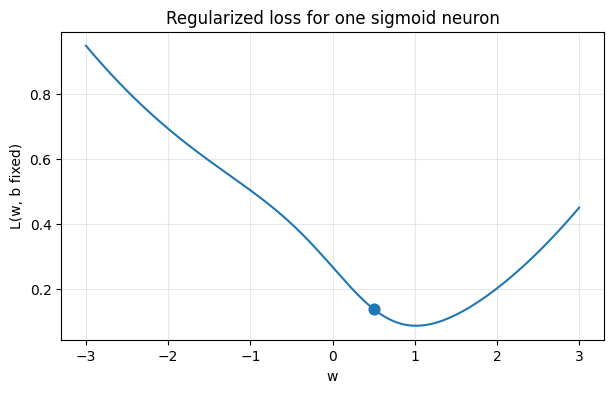

In [16]:
w_grid = np.linspace(-3.0, 3.0, 300)
loss_grid = np.array([loss_only(wi, b, x, t, lam) for wi in w_grid])

plt.figure(figsize=(7, 4))
plt.plot(w_grid, loss_grid)
plt.scatter([w], [loss_only(w, b, x, t, lam)], s=60)
plt.xlabel("w")
plt.ylabel("L(w, b fixed)")
plt.title("Regularized loss for one sigmoid neuron")
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
eta = 0.5

w_new = w - eta * grad_reverse[0]
b_new = b - eta * grad_reverse[1]

old_loss = loss_only(w, b, x, t, lam)
new_loss = loss_only(w_new, b_new, x, t, lam)

print(f"Old parameters: w={w:.6f}, b={b:.6f}, loss={old_loss:.6f}")
print(f"New parameters: w={w_new:.6f}, b={b_new:.6f}, loss={new_loss:.6f}")


Old parameters: w=0.500000, b=-1.000000, loss=0.137500
New parameters: w=0.600000, b=-0.937500, loss=0.112503


## 10. Discussion

1. **Why can forward mode produce a directional derivative in a single sweep?**
   Because it propagates both the value and its derivative together through the computation graph, following the chain rule in the chosen input direction.
2. **Why does reverse mode recover the full gradient of a scalar loss in one backward pass?**
   Because the loss is scalar, so one backward sweep propagates its sensitivity to all intermediate variables and parameters at once.
3. **Why do the data term and the regularization term contribute separately to $\partial L/\partial w$?**
   Because the loss is a sum of two terms, and differentiation is linear, so the derivative is the sum of the two corresponding contributions.
